# 04 — Train & Evaluate Logistic Regression (Final)

Objectif : entraîner le modèle final, évaluer sa capacité (paramètres) et visualiser ses performances complètes (Accuracy, AUC, ROC, Confiance) dans un seul notebook.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Java 17 Compatibility
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"

# 2. HADOOP_HOME Hack for Windows
project_root = str(Path(os.getcwd()).parent if "notebooks" in os.getcwd() else os.getcwd())
os.environ["HADOOP_HOME"] = project_root

spark = (
    SparkSession.builder
    .appName("AmazonFoodReviews-Train-LR")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.hadoop.fs.file.impl", "org.apache.hadoop.fs.RawLocalFileSystem")
    .getOrCreate()
)

DATA_PATH = Path("../data/Reviews.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../Reviews.csv")

MODEL_DIR = Path("../models/logreg_sentiment_tfidf")
print("Using dataset:", DATA_PATH.resolve())

Using dataset: C:\Users\lenovo\Desktop\Data Engineering\mini-projest 2\data\Reviews.csv


In [2]:
# Load + Process with multiLine and escape options
df_raw = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True, multiLine=True, escape='"')
df = (
    df_raw.select(
        F.col("Id").cast("long").alias("id"),
        F.col("Score").cast("int").alias("score"),
        F.col("Text").cast("string").alias("text"),
    )
    .filter(F.col("score").isNotNull())
    .na.drop(subset=["score", "text"])
    .withColumn("text", F.lower(F.col("text")))
    .withColumn("text", F.regexp_replace(F.col("text"), r"[^a-z0-9\s]", " "))
    .withColumn("text", F.regexp_replace(F.col("text"), r"\s+", " "))
    .withColumn(
        "sentiment",
        F.when(F.col("score").isin([1, 2]), F.lit("Negative"))
         .when(F.col("score") == 3, F.lit("Neutral"))
         .otherwise(F.lit("Positive"))
    )
)

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [3]:
# Train Pipeline
tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern=r"\W+")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="raw_features", numFeatures=20000)
idf = IDF(inputCol="raw_features", outputCol="features")
label_indexer = StringIndexer(inputCol="sentiment", outputCol="label")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=30)

pipeline = Pipeline(stages=[tokenizer, stopwords, hashing_tf, idf, label_indexer, lr])
pipeline_model = pipeline.fit(train_df)

predictions = pipeline_model.transform(test_df).cache()

## 1. Capacity & Performance Metrics

In [4]:
lr_model = pipeline_model.stages[-1]
print("=== Model Capacity ===")
print(f"Classes: {lr_model.numClasses}, Features: {lr_model.numFeatures}")

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
print(f"\nAccuracy: {evaluator.evaluate(predictions, {evaluator.metricName: 'accuracy'}):.4f}")
print(f"F1-Score: {evaluator.evaluate(predictions, {evaluator.metricName: 'f1'}):.4f}")

=== Model Capacity ===
Classes: 3, Features: 20000

Accuracy: 0.8654
F1-Score: 0.8569


## 2. Confusion Matrix & Per-Class Errors

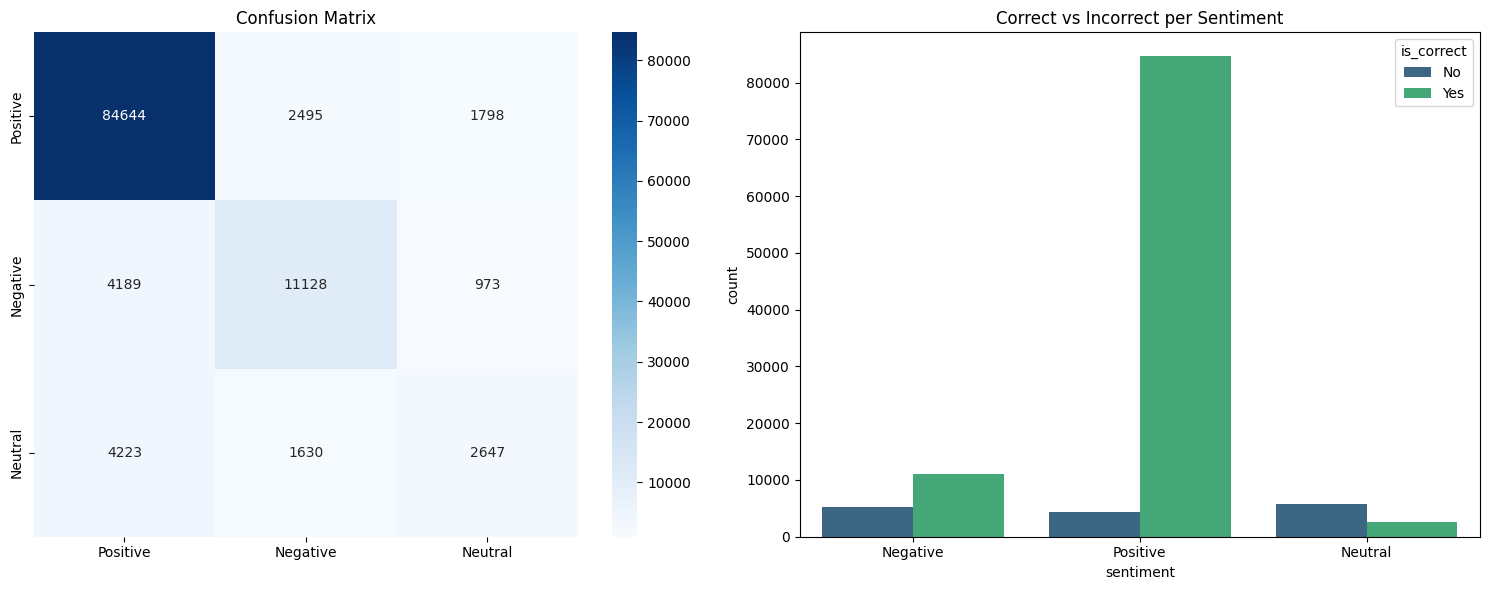

In [5]:
y_true = predictions.select("label").toPandas()
y_pred = predictions.select("prediction").toPandas()
labels = pipeline_model.stages[-2].labels

plt.figure(figsize=(15, 6))

# Subplot 1: Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")

# Subplot 2: Correct vs Incorrect
plt.subplot(1, 2, 2)
res_pd = predictions.withColumn("is_correct", F.when(F.col("label") == F.col("prediction"), "Yes").otherwise("No")) \
                    .groupBy("sentiment", "is_correct").count().toPandas()
sns.barplot(x="sentiment", y="count", hue="is_correct", data=res_pd, palette="viridis")
plt.title("Correct vs Incorrect per Sentiment")

plt.tight_layout()
plt.show()

## 3. ROC Curves & AUC

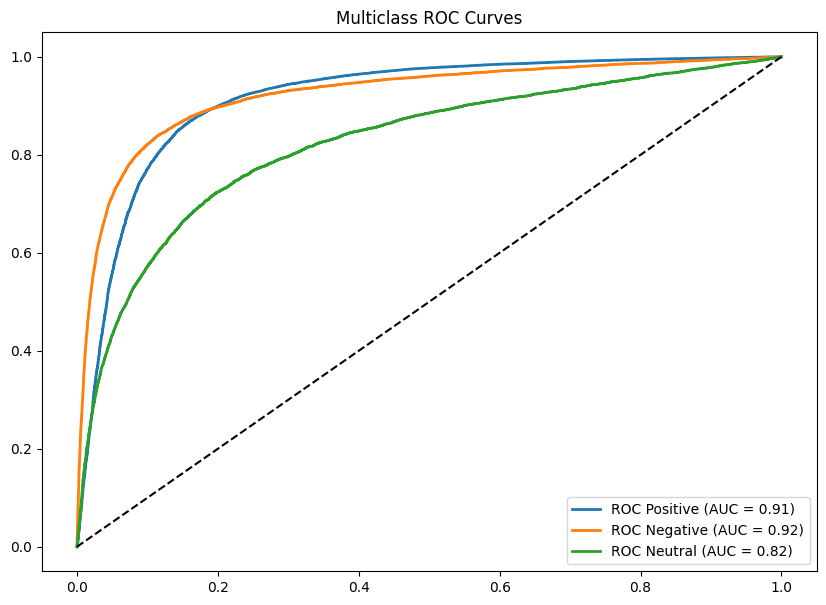

In [6]:
# Convert probability vector to array for ROC
prob_pd = predictions.select("label", vector_to_array("probability").alias("prob_arr")).toPandas()
y_score = np.stack(prob_pd['prob_arr'].values)
y_test_bin = label_binarize(prob_pd['label'], classes=[0, 1, 2])

plt.figure(figsize=(10, 7))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'ROC {labels[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()

## 4. Confidence Analysis

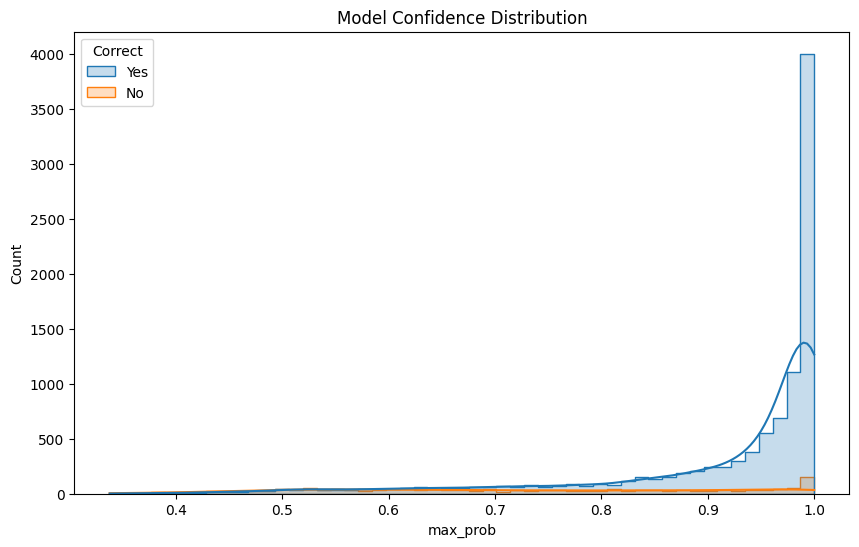

In [7]:
prob_pd = predictions.withColumn("max_prob", F.array_max(vector_to_array("probability"))) \
                     .withColumn("Correct", F.when(F.col("label") == F.col("prediction"), "Yes").otherwise("No")) \
                     .select("Correct", "max_prob").sample(0.1).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(data=prob_pd, x="max_prob", hue="Correct", kde=True, element="step")
plt.title("Model Confidence Distribution")
plt.show()

## 5. Save Model

In [8]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
abs_model_path = "file:///" + str(MODEL_DIR.resolve()).replace("\\", "/")

try:
    pipeline_model.write().overwrite().save(abs_model_path)
    print(f"Model saved successfully to: {abs_model_path}")
except Exception as e:
    print(f"Save failed: {e}")

Save failed: An error occurred while calling o766.save.
: java.lang.RuntimeException: java.io.FileNotFoundException: Hadoop bin directory does not exist: c:\Users\lenovo\Desktop\Data Engineering\mini-projest 2\bin -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
	at org.apache.hadoop.util.Shell.getWinUtilsPath(Shell.java:789)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:298)
	at org.apache.hadoop.util.Shell.getSetPermissionCommand(Shell.java:314)
	at org.apache.hadoop.fs.RawLocalFileSystem.setPermission(RawLocalFileSystem.java:1179)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkOneDirWithMode(RawLocalFileSystem.java:861)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:901)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirs(RawLocalFileSystem.java:873)
	at org.apache.hadoop.fs.RawLocalFileSystem.mkdirsWithOptionalPermission(RawLocalFileSystem.java:900)
	at org.apache.hadoop.fs.RawLocalFileSys